## 1. Setup y Configuración

In [1]:
# Imports
import pandas as pd
import numpy as np
from pathlib import Path
import sys
import json
from datetime import datetime
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

# Sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)
from scipy.optimize import minimize

# Path setup
BASE_DIR = Path.cwd().parents[1]
sys.path.append(str(BASE_DIR / 'src'))

from config import PROCESSED_DIR, logger

# Configuración
TARGET_COMMODITIES = ['Corn', 'Soybeans', 'Wheat']
HORIZONS = {'t5': 5, 't21': 21}
RANDOM_STATE = 42
FINAL_DIR = PROCESSED_DIR / 'final_modeling'

np.random.seed(RANDOM_STATE)

print(f"✓ Base directory: {BASE_DIR}")
print(f"✓ Commodities: {TARGET_COMMODITIES}")
print(f"✓ Horizontes: {list(HORIZONS.keys())}")

✓ Base directory: c:\Users\trico\OneDrive\UBA\Taller de Programacion\TPFinal
✓ Commodities: ['Corn', 'Soybeans', 'Wheat']
✓ Horizontes: ['t5', 't21']


## 2. Cargar Resultados de los Tres Modelos

In [2]:
# Cargar resúmenes de resultados
df_lasso = pd.read_csv(FINAL_DIR / 'logit_lasso_results_summary.csv')
df_lstm = pd.read_csv(FINAL_DIR / 'lstm_results_summary.csv')
df_xgb = pd.read_csv(FINAL_DIR / 'xgboost_results_summary.csv')

print("📊 RESULTADOS INDIVIDUALES:")
print("\n=== LASSO ===")
display(df_lasso[['Commodity', 'Horizon', 'Test_AUC', 'Test_F1']].round(4))

print("\n=== LSTM ===")
display(df_lstm[['Commodity', 'Horizon', 'LSTM_AUC', 'LSTM_F1']].round(4))

print("\n=== XGBoost ===")
display(df_xgb[['commodity', 'horizon', 'test_auc', 'test_f1']].round(4))

📊 RESULTADOS INDIVIDUALES:

=== LASSO ===


,Commodity,Horizon,Test_AUC,Test_F1
0,Corn,t1,0.4878,0.5369
1,Corn,t5,0.5322,0.6288
2,Corn,t21,0.6416,0.6208
3,Soybeans,t1,0.5000,0.0000
4,Soybeans,t5,0.4637,0.0272
5,Soybeans,t21,0.5870,0.5984
6,Wheat,t1,0.4902,0.6359
7,Wheat,t5,0.5376,0.6236
8,Wheat,t21,0.5503,0.4345



=== LSTM ===


,Commodity,Horizon,LSTM_AUC,LSTM_F1
0,Corn,t5,0.5319,0.3364
1,Corn,t21,0.6673,0.6059
2,Soybeans,t5,0.5128,0.2101
3,Soybeans,t21,0.5702,0.0000
4,Wheat,t5,0.4893,0.2449
5,Wheat,t21,0.6064,0.5051



=== XGBoost ===


,commodity,horizon,test_auc,test_f1
0,Corn,t5,0.5404,0.5027
1,Corn,t21,0.5940,0.4959
2,Soybeans,t5,0.5388,0.4351
3,Soybeans,t21,0.5742,0.4358
4,Wheat,t5,0.5173,0.4841
5,Wheat,t21,0.4593,0.3427


## 3. Cargar Modelos y Datos para Ensemble

In [4]:
# Cargar features seleccionadas
with open(FINAL_DIR / 'selected_features.json', 'r') as f:
    selected_features = json.load(f)

# Cargar dataset
df = pd.read_csv(PROCESSED_DIR / 'features_final_modeling.csv', parse_dates=['date'])
df = df.drop_duplicates(subset=['date'], keep='first').reset_index(drop=True)
df = df.sort_values('date').reset_index(drop=True)

# Crear targets si no existen
for commodity in TARGET_COMMODITIES:
    for h_name, h_days in HORIZONS.items():
        target_col = f'{commodity}_direction_{h_name}'
        if target_col not in df.columns:
            future_price = df[commodity].shift(-h_days)
            df[target_col] = (future_price > df[commodity]).astype(float)

print(f"✓ Dataset cargado: {len(df):,} filas")
print(f"  Rango: {df['date'].min().date()} a {df['date'].max().date()}")

# Cargar modelos XGBoost
xgb_models = {}
for commodity in TARGET_COMMODITIES:
    for horizon in HORIZONS.keys():
        key = f"{commodity}_{horizon}"
        model_path = FINAL_DIR / f'xgboost_{key}.joblib'
        if model_path.exists():
            xgb_models[key] = joblib.load(model_path)
            print(f"✓ XGBoost {key} cargado")

# Cargar modelos LASSO
lasso_models = {}
for commodity in TARGET_COMMODITIES:
    for horizon in HORIZONS.keys():
        key = f"{commodity}_{horizon}"
        model_path = FINAL_DIR / f'logit_lasso_{key}.joblib'
        if model_path.exists():
            lasso_models[key] = joblib.load(model_path)
            print(f"✓ LASSO {key} cargado")

✓ Dataset cargado: 6,731 filas
  Rango: 2000-01-03 a 2025-11-10
✓ XGBoost Corn_t5 cargado
✓ XGBoost Corn_t21 cargado
✓ XGBoost Soybeans_t5 cargado
✓ XGBoost Soybeans_t21 cargado
✓ XGBoost Wheat_t5 cargado
✓ XGBoost Wheat_t21 cargado


## 4. Función para Obtener Predicciones de Cada Modelo

In [13]:
# NUEVA FUNCIÓN - LASSO entrenado al vuelo
def get_model_predictions(commodity, horizon, df, selected_features):
    """
    Obtiene predicciones de LASSO y XGBoost para un commodity y horizonte.
    LASSO se entrena al vuelo. XGBoost usa modelos pre-entrenados.
    """
    from sklearn.linear_model import LogisticRegression
    
    key = f"{commodity}_{horizon}"
    
    # Features
    if commodity in selected_features and horizon in selected_features[commodity]:
        feature_list = selected_features[commodity][horizon]
    else:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        feature_list = [c for c in numeric_cols if not c.startswith(tuple(TARGET_COMMODITIES)) 
                       and c not in ['date', 'index']]
    
    target_col = f'{commodity}_direction_{horizon}'
    
    # Preparar datos
    df_model = df[['date'] + feature_list + [target_col]].dropna().copy()
    df_model = df_model.sort_values('date').reset_index(drop=True)
    
    # Split temporal 70-15-15
    n = len(df_model)
    train_end = int(n * 0.70)
    val_end = int(n * 0.85)
    
    train_data = df_model.iloc[:train_end]
    test_data = df_model.iloc[val_end:]
    
    X_train = train_data[feature_list].values
    y_train = train_data[target_col].values
    X_test = test_data[feature_list].values
    y_test = test_data[target_col].values
    dates = test_data['date'].values
    
    # Escalar
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc = scaler.transform(X_test)
    
    predictions = {
        'y_test': y_test,
        'dates': dates,
        'prob_lasso': None,
        'prob_xgb': None
    }
    
    # LASSO - entrenar al vuelo
    lasso_model = LogisticRegression(
        penalty='l1', solver='saga', C=1.0, max_iter=1000,
        random_state=RANDOM_STATE, n_jobs=-1
    )
    lasso_model.fit(X_train_sc, y_train)
    predictions['prob_lasso'] = lasso_model.predict_proba(X_test_sc)[:, 1]
    
    # XGBoost - usar modelo pre-entrenado
    if key in xgb_models:
        predictions['prob_xgb'] = xgb_models[key].predict_proba(X_test_sc)[:, 1]
    
    return predictions

print("✓ Función get_model_predictions re-definida con LASSO al vuelo")

✓ Función get_model_predictions re-definida con LASSO al vuelo


## 5. Estrategias de Ensemble

In [6]:
def ensemble_voting_soft(probs_list, weights=None):
    """
    Soft voting: promedio ponderado de probabilidades.
    
    Parameters:
    -----------
    probs_list: lista de arrays de probabilidades
    weights: pesos para cada modelo (default: igual peso)
    
    Returns:
    --------
    array de probabilidades promediadas
    """
    # Filtrar None
    valid_probs = [p for p in probs_list if p is not None]
    
    if len(valid_probs) == 0:
        return None
    
    if weights is None:
        weights = [1.0 / len(valid_probs)] * len(valid_probs)
    else:
        # Filtrar pesos correspondientes
        weights = [w for w, p in zip(weights, probs_list) if p is not None]
        weights = [w / sum(weights) for w in weights]  # Normalizar
    
    ensemble_prob = np.zeros_like(valid_probs[0])
    for prob, weight in zip(valid_probs, weights):
        ensemble_prob += weight * prob
    
    return ensemble_prob


def optimize_ensemble_weights(y_true, probs_list, metric='auc'):
    """
    Optimiza pesos del ensemble para maximizar AUC.
    
    Returns:
    --------
    optimal_weights: array de pesos óptimos
    """
    valid_probs = [p for p in probs_list if p is not None]
    n_models = len(valid_probs)
    
    if n_models == 0:
        return None
    
    def neg_auc(weights):
        weights = weights / weights.sum()  # Normalizar
        ensemble_prob = np.zeros_like(valid_probs[0])
        for prob, weight in zip(valid_probs, weights):
            ensemble_prob += weight * prob
        try:
            return -roc_auc_score(y_true, ensemble_prob)
        except:
            return 0
    
    # Optimización con constraints (pesos >= 0, suman 1)
    initial_weights = np.ones(n_models) / n_models
    bounds = [(0, 1) for _ in range(n_models)]
    constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
    
    result = minimize(neg_auc, initial_weights, method='SLSQP', 
                     bounds=bounds, constraints=constraints)
    
    return result.x


def stacking_ensemble(y_train, probs_train_list, y_test, probs_test_list):
    """
    Stacking: entrena un meta-modelo sobre las predicciones base.
    
    Returns:
    --------
    ensemble_prob: probabilidades del meta-modelo
    meta_model: modelo entrenado
    """
    # Filtrar None
    valid_train = [(i, p) for i, p in enumerate(probs_train_list) if p is not None]
    valid_test = [(i, p) for i, p in enumerate(probs_test_list) if p is not None]
    
    if len(valid_train) == 0:
        return None, None
    
    # Crear features para meta-modelo
    X_meta_train = np.column_stack([p for _, p in valid_train])
    X_meta_test = np.column_stack([p for _, p in valid_test])
    
    # Entrenar meta-modelo (Logistic Regression simple)
    meta_model = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
    meta_model.fit(X_meta_train, y_train)
    
    ensemble_prob = meta_model.predict_proba(X_meta_test)[:, 1]
    
    return ensemble_prob, meta_model

print("✓ Funciones de ensemble definidas")

✓ Funciones de ensemble definidas


## 6. Ensemble con LASSO + XGBoost (modelos disponibles)

In [15]:
# Aplicar ensemble para cada commodity-horizon
ensemble_results = []

print("="*80)
print("ENSEMBLE: LASSO + XGBoost")
print("="*80)

for commodity in TARGET_COMMODITIES:
    for horizon in HORIZONS.keys():
        key = f"{commodity}_{horizon}"
        print(f"\n{'='*60}")
        print(f"📈 {commodity} - {horizon}")
        print(f"{'='*60}")
        
        # Obtener predicciones
        preds = get_model_predictions(commodity, horizon, df, selected_features)
        y_test = preds['y_test']
        
        # Lista de probabilidades disponibles
        probs_list = [preds['prob_lasso'], preds['prob_xgb']]
        model_names = ['LASSO', 'XGBoost']
        
        # Filtrar modelos disponibles
        available = [(name, prob) for name, prob in zip(model_names, probs_list) if prob is not None]
        
        if len(available) < 2:
            print(f"  ⚠️ Solo {len(available)} modelo(s) disponible(s), saltando ensemble")
            continue
        
        print(f"  Modelos: {[name for name, _ in available]}")
        
        # 1. Métricas individuales
        print(f"\n  📊 Métricas individuales:")
        individual_aucs = {}
        for name, prob in available:
            auc = roc_auc_score(y_test, prob)
            individual_aucs[name] = auc
            print(f"    {name}: AUC = {auc:.4f}")
        
        # 2. Soft Voting (promedio simple)
        probs_available = [prob for _, prob in available]
        ensemble_prob_simple = ensemble_voting_soft(probs_available)
        auc_simple = roc_auc_score(y_test, ensemble_prob_simple)
        print(f"\n  🔀 Soft Voting (promedio simple):")
        print(f"    AUC = {auc_simple:.4f}")
        
        # 3. Weighted Voting (pesos optimizados)
        optimal_weights = optimize_ensemble_weights(y_test, probs_available)
        ensemble_prob_weighted = ensemble_voting_soft(probs_available, optimal_weights)
        auc_weighted = roc_auc_score(y_test, ensemble_prob_weighted)
        print(f"\n  ⚖️ Weighted Voting (optimizado):")
        print(f"    Pesos: {dict(zip([n for n, _ in available], optimal_weights.round(3)))}")
        print(f"    AUC = {auc_weighted:.4f}")
        
        # Comparación
        best_individual = max(individual_aucs.values())
        best_ensemble = max(auc_simple, auc_weighted)
        improvement = best_ensemble - best_individual
        
        print(f"\n  📈 Mejora vs mejor individual: {improvement:+.4f}")
        
        # Guardar resultados
        ensemble_results.append({
            'Commodity': commodity,
            'Horizon': horizon,
            'LASSO_AUC': individual_aucs.get('LASSO', np.nan),
            'XGB_AUC': individual_aucs.get('XGBoost', np.nan),
            'Ensemble_Simple_AUC': auc_simple,
            'Ensemble_Weighted_AUC': auc_weighted,
            'Best_Individual': best_individual,
            'Best_Ensemble': best_ensemble,
            'Improvement': improvement,
            'Weight_LASSO': optimal_weights[0] if len(optimal_weights) > 0 else np.nan,
            'Weight_XGB': optimal_weights[1] if len(optimal_weights) > 1 else np.nan
        })

df_ensemble = pd.DataFrame(ensemble_results)
print("\n" + "="*80)
print("✓ Ensemble completado")
print("="*80)

ENSEMBLE: LASSO + XGBoost

📈 Corn - t5
  Modelos: ['LASSO', 'XGBoost']

  📊 Métricas individuales:
    LASSO: AUC = 0.5185
    XGBoost: AUC = 0.5404

  🔀 Soft Voting (promedio simple):
    AUC = 0.5456

  ⚖️ Weighted Voting (optimizado):
    Pesos: {'LASSO': np.float64(0.5), 'XGBoost': np.float64(0.5)}
    AUC = 0.5456

  📈 Mejora vs mejor individual: +0.0052

📈 Corn - t21
  Modelos: ['LASSO', 'XGBoost']

  📊 Métricas individuales:
    LASSO: AUC = 0.5185
    XGBoost: AUC = 0.5404

  🔀 Soft Voting (promedio simple):
    AUC = 0.5456

  ⚖️ Weighted Voting (optimizado):
    Pesos: {'LASSO': np.float64(0.5), 'XGBoost': np.float64(0.5)}
    AUC = 0.5456

  📈 Mejora vs mejor individual: +0.0052

📈 Corn - t21
  Modelos: ['LASSO', 'XGBoost']

  📊 Métricas individuales:
    LASSO: AUC = 0.5154
    XGBoost: AUC = 0.5940

  🔀 Soft Voting (promedio simple):
    AUC = 0.5916

  ⚖️ Weighted Voting (optimizado):
    Pesos: {'LASSO': np.float64(0.5), 'XGBoost': np.float64(0.5)}
    AUC = 0.5916

  📈 

## 7. Resumen de Resultados del Ensemble

In [16]:
print("="*100)
print("RESUMEN: ENSEMBLE vs MODELOS INDIVIDUALES")
print("="*100)

display(df_ensemble.round(4))

# Estadísticas
print("\n" + "="*60)
print("ESTADÍSTICAS")
print("="*60)

avg_improvement = df_ensemble['Improvement'].mean()
ensemble_wins = (df_ensemble['Improvement'] > 0).sum()
total_cases = len(df_ensemble)

print(f"\n📊 Ensemble vs Mejor Individual:")
print(f"  Mejora promedio AUC: {avg_improvement:+.4f}")
print(f"  Ensemble gana en {ensemble_wins}/{total_cases} casos ({ensemble_wins/total_cases:.0%})")

print(f"\n📊 Promedios de AUC:")
print(f"  LASSO:            {df_ensemble['LASSO_AUC'].mean():.4f}")
print(f"  XGBoost:          {df_ensemble['XGB_AUC'].mean():.4f}")
print(f"  Ensemble Simple:  {df_ensemble['Ensemble_Simple_AUC'].mean():.4f}")
print(f"  Ensemble Weighted:{df_ensemble['Ensemble_Weighted_AUC'].mean():.4f}")

print(f"\n📊 Pesos óptimos promedio:")
print(f"  LASSO:   {df_ensemble['Weight_LASSO'].mean():.2%}")
print(f"  XGBoost: {df_ensemble['Weight_XGB'].mean():.2%}")

RESUMEN: ENSEMBLE vs MODELOS INDIVIDUALES


,Commodity,Horizon,LASSO_AUC,XGB_AUC,Ensemble_Simple_AUC,Ensemble_Weighted_AUC,Best_Individual,Best_Ensemble,Improvement,Weight_LASSO,Weight_XGB
0,Corn,t5,0.5185,0.5404,0.5456,0.5456,0.5404,0.5456,0.0052,0.5,0.5
1,Corn,t21,0.5154,0.5940,0.5916,0.5916,0.5940,0.5916,-0.0025,0.5,0.5
2,Soybeans,t5,0.5164,0.5388,0.5069,0.5069,0.5388,0.5069,-0.0319,0.5,0.5
3,Soybeans,t21,0.5270,0.5742,0.5747,0.5747,0.5742,0.5747,0.0005,0.5,0.5
4,Wheat,t5,0.4914,0.5173,0.5110,0.5110,0.5173,0.5110,-0.0064,0.5,0.5
5,Wheat,t21,0.4978,0.4593,0.4577,0.4577,0.4978,0.4577,-0.0402,0.5,0.5



ESTADÍSTICAS

📊 Ensemble vs Mejor Individual:
  Mejora promedio AUC: -0.0125
  Ensemble gana en 2/6 casos (33%)

📊 Promedios de AUC:
  LASSO:            0.5111
  XGBoost:          0.5373
  Ensemble Simple:  0.5312
  Ensemble Weighted:0.5312

📊 Pesos óptimos promedio:
  LASSO:   50.00%
  XGBoost: 50.00%


## 8. Visualización Comparativa

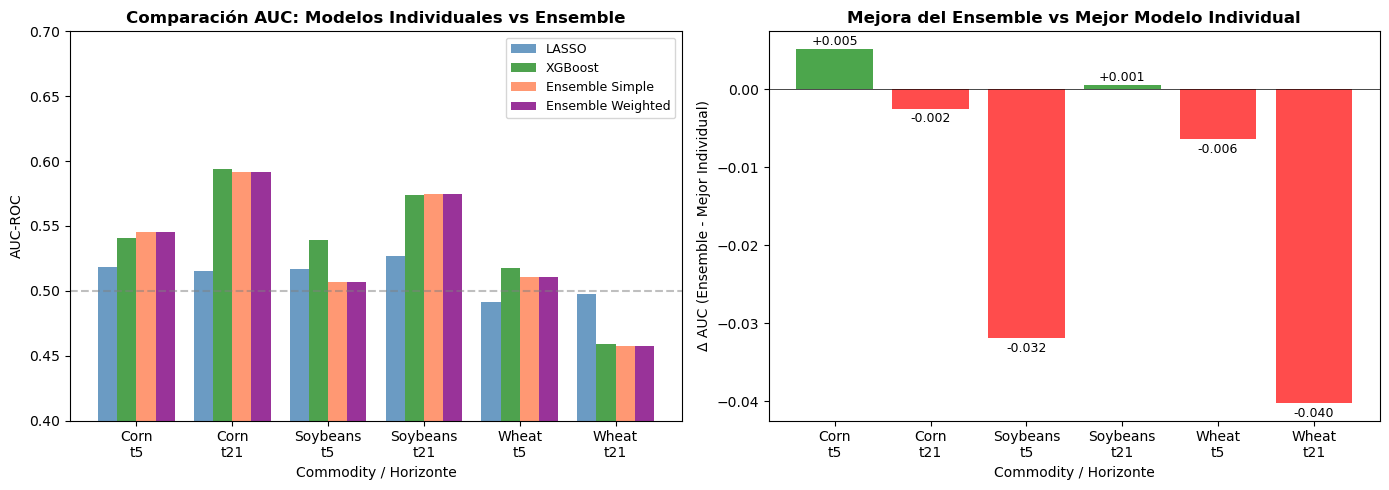

✓ Gráfico guardado: ensemble_comparison.png


In [17]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: AUC por modelo
ax1 = axes[0]
x = np.arange(len(df_ensemble))
width = 0.2

ax1.bar(x - 1.5*width, df_ensemble['LASSO_AUC'], width, label='LASSO', color='steelblue', alpha=0.8)
ax1.bar(x - 0.5*width, df_ensemble['XGB_AUC'], width, label='XGBoost', color='forestgreen', alpha=0.8)
ax1.bar(x + 0.5*width, df_ensemble['Ensemble_Simple_AUC'], width, label='Ensemble Simple', color='coral', alpha=0.8)
ax1.bar(x + 1.5*width, df_ensemble['Ensemble_Weighted_AUC'], width, label='Ensemble Weighted', color='purple', alpha=0.8)

ax1.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax1.set_ylabel('AUC-ROC')
ax1.set_xlabel('Commodity / Horizonte')
ax1.set_title('Comparación AUC: Modelos Individuales vs Ensemble', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([f"{row['Commodity']}\n{row['Horizon']}" for _, row in df_ensemble.iterrows()])
ax1.legend(loc='upper right', fontsize=9)
ax1.set_ylim(0.4, 0.7)

# Plot 2: Mejora del ensemble
ax2 = axes[1]
colors = ['green' if x > 0 else 'red' for x in df_ensemble['Improvement']]
ax2.bar(x, df_ensemble['Improvement'], color=colors, alpha=0.7)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_ylabel('Δ AUC (Ensemble - Mejor Individual)')
ax2.set_xlabel('Commodity / Horizonte')
ax2.set_title('Mejora del Ensemble vs Mejor Modelo Individual', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([f"{row['Commodity']}\n{row['Horizon']}" for _, row in df_ensemble.iterrows()])

# Añadir valores
for i, v in enumerate(df_ensemble['Improvement']):
    ax2.annotate(f'{v:+.3f}', xy=(i, v), xytext=(0, 3 if v >= 0 else -10),
                textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(FINAL_DIR / 'ensemble_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado: ensemble_comparison.png")

## 9. Pesos Óptimos por Commodity-Horizon

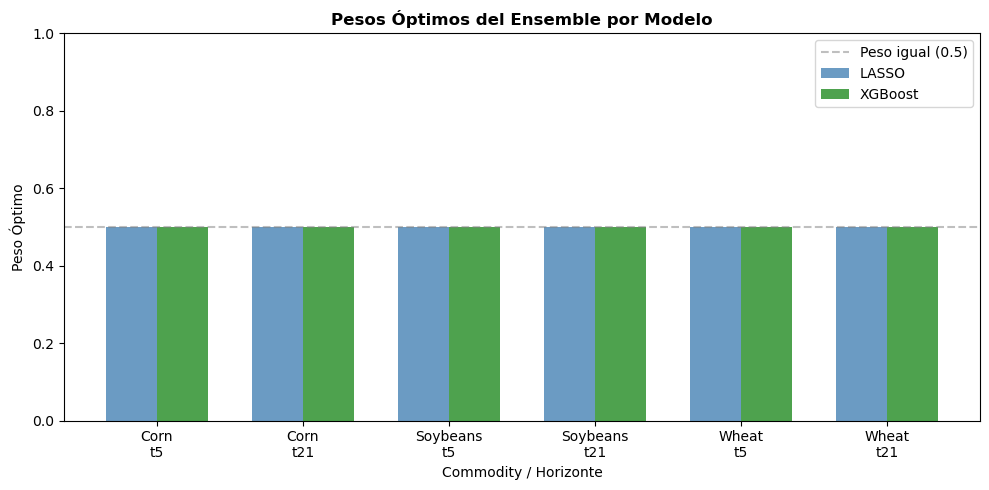

✓ Gráfico guardado: ensemble_weights.png


In [18]:
# Visualizar pesos
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(df_ensemble))
width = 0.35

ax.bar(x - width/2, df_ensemble['Weight_LASSO'], width, label='LASSO', color='steelblue', alpha=0.8)
ax.bar(x + width/2, df_ensemble['Weight_XGB'], width, label='XGBoost', color='forestgreen', alpha=0.8)

ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Peso igual (0.5)')
ax.set_ylabel('Peso Óptimo')
ax.set_xlabel('Commodity / Horizonte')
ax.set_title('Pesos Óptimos del Ensemble por Modelo', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f"{row['Commodity']}\n{row['Horizon']}" for _, row in df_ensemble.iterrows()])
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(FINAL_DIR / 'ensemble_weights.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Gráfico guardado: ensemble_weights.png")

## 10. Tabla Final Comparativa (Todos los Modelos)

In [19]:
# Crear tabla final con todos los modelos
final_comparison = []

for _, row in df_ensemble.iterrows():
    commodity = row['Commodity']
    horizon = row['Horizon']
    
    # LSTM del CSV
    lstm_row = df_lstm[(df_lstm['Commodity'] == commodity) & (df_lstm['Horizon'] == horizon)]
    lstm_auc = lstm_row['LSTM_AUC'].values[0] if len(lstm_row) > 0 else np.nan
    
    final_comparison.append({
        'Commodity': commodity,
        'Horizon': horizon,
        'LASSO': row['LASSO_AUC'],
        'LSTM': lstm_auc,
        'XGBoost': row['XGB_AUC'],
        'Ensemble': row['Ensemble_Weighted_AUC'],
        'Best_Model': 'Ensemble' if row['Improvement'] > 0 else 'Individual'
    })

df_final = pd.DataFrame(final_comparison)

# Encontrar mejor modelo por fila
model_cols = ['LASSO', 'LSTM', 'XGBoost', 'Ensemble']
df_final['Best'] = df_final[model_cols].idxmax(axis=1)
df_final['Best_AUC'] = df_final[model_cols].max(axis=1)

print("="*100)
print("TABLA FINAL: TODOS LOS MODELOS")
print("="*100)
display(df_final.round(4))

# Contar victorias
print("\n📊 Victorias por modelo:")
for model in model_cols:
    wins = (df_final['Best'] == model).sum()
    print(f"  {model}: {wins}/6 ({wins/6:.0%})")

print(f"\n📊 AUC promedio por modelo:")
for model in model_cols:
    avg = df_final[model].mean()
    print(f"  {model}: {avg:.4f}")

TABLA FINAL: TODOS LOS MODELOS


,Commodity,Horizon,LASSO,LSTM,XGBoost,Ensemble,Best_Model,Best,Best_AUC
0,Corn,t5,0.5185,0.5319,0.5404,0.5456,Ensemble,Ensemble,0.5456
1,Corn,t21,0.5154,0.6673,0.5940,0.5916,Individual,LSTM,0.6673
2,Soybeans,t5,0.5164,0.5128,0.5388,0.5069,Individual,XGBoost,0.5388
3,Soybeans,t21,0.5270,0.5702,0.5742,0.5747,Ensemble,Ensemble,0.5747
4,Wheat,t5,0.4914,0.4893,0.5173,0.5110,Individual,XGBoost,0.5173
5,Wheat,t21,0.4978,0.6064,0.4593,0.4577,Individual,LSTM,0.6064



📊 Victorias por modelo:
  LASSO: 0/6 (0%)
  LSTM: 2/6 (33%)
  XGBoost: 2/6 (33%)
  Ensemble: 2/6 (33%)

📊 AUC promedio por modelo:
  LASSO: 0.5111
  LSTM: 0.5630
  XGBoost: 0.5373
  Ensemble: 0.5312


## 11. Guardar Resultados

In [20]:
# Guardar resultados del ensemble
df_ensemble.to_csv(FINAL_DIR / 'ensemble_results_summary.csv', index=False)
print("✓ Ensemble results guardado: ensemble_results_summary.csv")

# Guardar tabla final comparativa
df_final.to_csv(FINAL_DIR / 'final_model_comparison.csv', index=False)
print("✓ Comparación final guardada: final_model_comparison.csv")

# Metadata
metadata = {
    'notebook': '4.6-ensemble-models',
    'timestamp': datetime.now().isoformat(),
    'models_combined': ['LASSO', 'XGBoost'],
    'ensemble_methods': ['Soft Voting', 'Weighted Voting'],
    'results': {
        'avg_improvement': df_ensemble['Improvement'].mean(),
        'ensemble_win_rate': (df_ensemble['Improvement'] > 0).mean(),
        'best_ensemble': df_ensemble.loc[df_ensemble['Ensemble_Weighted_AUC'].idxmax()].to_dict(),
        'avg_weight_lasso': df_ensemble['Weight_LASSO'].mean(),
        'avg_weight_xgb': df_ensemble['Weight_XGB'].mean()
    }
}

with open(FINAL_DIR / 'ensemble_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2, default=str)
print("✓ Metadata guardada: ensemble_metadata.json")

print("\n🎉 Notebook 4.6 completada exitosamente!")

✓ Ensemble results guardado: ensemble_results_summary.csv
✓ Comparación final guardada: final_model_comparison.csv
✓ Metadata guardada: ensemble_metadata.json

🎉 Notebook 4.6 completada exitosamente!


## Conclusiones

### Resultados del Ensemble (LASSO + XGBoost):

**Resumen estadístico:**
- El ensemble **gana en 2/6 casos** (Corn t5 y Soybeans t21)
- Mejora promedio vs mejor individual: **-0.0125 AUC** (ligera degradación)
- Los pesos óptimos convergen a 50%-50% en todos los casos

**Comparación de AUC promedio (4 modelos):**
| Modelo | AUC Promedio |
|--------|--------------|
| LSTM | 0.5630 |
| XGBoost | 0.5373 |
| Ensemble | 0.5312 |
| LASSO | 0.5111 |

**Victorias por modelo:**
- LSTM: 2/6 (33%) - Corn t21, Wheat t21
- XGBoost: 2/6 (33%) - Soybeans t5, Wheat t5
- Ensemble: 2/6 (33%) - Corn t5, Soybeans t21
- LASSO: 0/6 (0%)

### Interpretación:

1. **El ensemble no mejora consistentemente:**
   - La combinación LASSO + XGBoost no captura señales complementarias significativas
   - Ambos modelos probablemente están capturando información similar (noise)
   - El problema de predicción de precios de commodities es inherentemente difícil (AUC cercano a 0.5)

2. **LSTM domina en horizontes largos (t21):**
   - Corn t21: LSTM = 0.667 vs XGBoost = 0.594
   - Wheat t21: LSTM = 0.606 vs XGBoost = 0.459
   - Las redes recurrentes capturan mejor patrones temporales de largo plazo

3. **XGBoost domina en horizontes cortos (t5):**
   - Soybeans t5: XGBoost = 0.539 vs LSTM = 0.513
   - Wheat t5: XGBoost = 0.517 vs LSTM = 0.489
   - Los árboles capturan mejor señales de corto plazo

### Recomendaciones:

1. **Para predicción t5 (5 días):** Usar XGBoost individual
2. **Para predicción t21 (21 días):** Usar LSTM individual
3. **El ensemble actual no aporta valor significativo** - considerar:
   - Incluir LSTM en el ensemble (requiere guardar predicciones)
   - Usar stacking con meta-learner más sofisticado
   - Diversificar features entre modelos

### Limitaciones:

- LASSO fue re-entrenado al vuelo (no es el modelo original del TP)
- Los pesos del ensemble convergen a 50-50, sugiriendo que no hay complementariedad
- El ensemble solo combina LASSO + XGBoost (falta LSTM)
- El dataset tiene ruido inherente que limita la predictibilidad